# Travel MLOps Capstone Project - Classification Model
## User Gender Classification using Machine Learning

### Project Summary
This notebook implements a classification model to predict user gender based on travel behavior patterns from the flights and hotels datasets. The model analyzes booking patterns, preferences, and travel characteristics to classify users.

### GitHub Repository
**GitHub Link:** https://github.com/Kalpesh-Rajput/Integrating_MLOps_in_Travel_Productionization_of_ML_Systems/tree/main

---

## 1. Import Libraries

In [ ]:
# Install required libraries  # revamp_1
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost joblib imbalanced-learn -q  # revamp_2


In [3]:
# Import necessary libraries  # revamp_1
import pandas as pd  # revamp_2
import numpy as np  # revamp_3
import matplotlib.pyplot as plt  # revamp_4
import seaborn as sns  # revamp_5
import warnings  # revamp_6
warnings.filterwarnings('ignore')  # revamp_7

# ML Libraries  # revamp_9
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV  # revamp_10
from sklearn.preprocessing import LabelEncoder, StandardScaler  # revamp_11
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # revamp_12
from sklearn.linear_model import LogisticRegression  # revamp_13
from sklearn.tree import DecisionTreeClassifier  # revamp_14
from sklearn.svm import SVC  # revamp_15
from sklearn.naive_bayes import GaussianNB  # revamp_16
from xgboost import XGBClassifier  # revamp_17
from sklearn.metrics import (  # revamp_18
    accuracy_score, precision_score, recall_score, f1_score,  # revamp_19
    confusion_matrix, classification_report, roc_auc_score, roc_curve  # revamp_20
)  # revamp_21
from imblearn.over_sampling import SMOTE  # revamp_22
import joblib  # revamp_23

# Set display options  # revamp_25
pd.set_option('display.max_columns', None)  # revamp_26
sns.set_style('whitegrid')  # revamp_27

print("✓ All libraries imported successfully!")  # revamp_29


✓ All libraries imported successfully!


## 2. Load and Merge Datasets

In [1]:
from google.colab import drive  # revamp_1
drive.mount('/content/drive')  # revamp_2


Mounted at /content/drive


In [4]:
# Load datasets  # revamp_1
flights_df = pd.read_csv('/content/drive/MyDrive/MS : Data Science & AI/01 - Voyage Analytics: Integrating MLOps in Travel Productionization of ML Systems/DataSet/flights.csv' , on_bad_lines='skip')  # revamp_2
users_df = pd.read_csv('/content/drive/MyDrive/MS : Data Science & AI/01 - Voyage Analytics: Integrating MLOps in Travel Productionization of ML Systems/DataSet/users.csv',on_bad_lines='skip')  # revamp_3
hotels_df = pd.read_csv('/content/drive/MyDrive/MS : Data Science & AI/01 - Voyage Analytics: Integrating MLOps in Travel Productionization of ML Systems/DataSet/hotels.csv',on_bad_lines='skip')  # revamp_4


print(f"Flights dataset: {flights_df.shape}")  # revamp_7
print(f"Users dataset: {users_df.shape}")  # revamp_8
print(f"Hotels dataset: {hotels_df.shape}")  # revamp_9

# Display users data  # revamp_11
print("\nUsers Dataset Sample:")  # revamp_12
display(users_df.head(10))  # revamp_13

# Check gender distribution  # revamp_15
print("\nGender Distribution:")  # revamp_16
print(users_df['gender'].value_counts())  # revamp_17
print(f"\nPercentages:")  # revamp_18
print(users_df['gender'].value_counts(normalize=True) * 100)  # revamp_19


Flights dataset: (271888, 10)
Users dataset: (1340, 5)
Hotels dataset: (40552, 8)

Users Dataset Sample:


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44
5,5,4You,Trina Thomas,none,47
6,6,4You,Jesse Decelle,male,46
7,7,4You,Gregoria Gil,female,21
8,8,4You,Jack Sabo,none,41
9,9,4You,Debbie Helms,none,35



Gender Distribution:
gender
male      452
female    448
none      440
Name: count, dtype: int64

Percentages:
gender
male      33.731343
female    33.432836
none      32.835821
Name: proportion, dtype: float64


### Dataset Understanding

**Classification Task**: Predict user gender (male/female/none) based on travel patterns

**Approach**: We'll aggregate travel behavior features from flights and hotels datasets:
- Number of trips taken
- Preferred flight types
- Average spending
- Hotel preferences
- Travel frequency patterns

## 3. Feature Engineering for Classification

In [5]:
# Aggregate flight features per user  # revamp_1
flight_features = flights_df.groupby('userCode').agg({  # revamp_2
    'travelCode': 'count',  # Total number of flights  # revamp_3
    'price': ['mean', 'sum', 'std'],  # Spending patterns  # revamp_4
    'distance': ['mean', 'sum'],  # Travel distance patterns  # revamp_5
    'time': ['mean', 'sum'],  # Time spent traveling  # revamp_6
}).reset_index()  # revamp_7

# Flatten column names  # revamp_9
flight_features.columns = ['userCode', 'total_flights', 'avg_flight_price',  # revamp_10
                           'total_flight_spend', 'std_flight_price',  # revamp_11
                           'avg_distance', 'total_distance',  # revamp_12
                           'avg_flight_time', 'total_flight_time']  # revamp_13

print("Flight features created:")  # revamp_15
display(flight_features.head())  # revamp_16


Flight features created:


,userCode,total_flights,avg_flight_price,total_flight_spend,std_flight_price,avg_distance,total_distance,avg_flight_time,total_flight_time
0,0,178,989.066124,176053.77,370.237372,527.233596,93847.58,1.370337,243.92
1,1,12,818.898333,9826.78,196.008184,508.648333,6103.78,1.321667,15.86
2,2,262,906.921832,237613.52,357.965935,513.671374,134581.90,1.335191,349.82
3,3,398,936.913894,372891.73,359.765705,506.074372,201417.60,1.315176,523.44
4,4,398,957.393417,381042.58,372.719529,517.955477,206146.28,1.345930,535.68


In [6]:
# Aggregate hotel features per user  # revamp_1
hotel_features = hotels_df.groupby('userCode').agg({  # revamp_2
    'travelCode': 'count',  # Total number of hotel bookings  # revamp_3
    'days': ['mean', 'sum'],  # Stay duration patterns  # revamp_4
    'price': ['mean'],  # Average hotel price per day  # revamp_5
    'total': ['mean', 'sum']  # Total hotel spending  # revamp_6
}).reset_index()  # revamp_7

# Flatten column names  # revamp_9
hotel_features.columns = ['userCode', 'total_hotel_bookings', 'avg_stay_days',  # revamp_10
                          'total_stay_days', 'avg_hotel_price_per_day',  # revamp_11
                          'avg_total_hotel_spend', 'total_hotel_spend']  # revamp_12

print("Hotel features created:")  # revamp_14
display(hotel_features.head())  # revamp_15


Hotel features created:


,userCode,total_hotel_bookings,avg_stay_days,total_stay_days,avg_hotel_price_per_day,avg_total_hotel_spend,total_hotel_spend
0,0,27,2.629630,71,225.741481,593.145185,16014.92
1,1,2,1.000000,2,193.360000,193.360000,386.72
2,2,36,2.694444,97,210.050000,558.003333,20088.12
3,3,60,2.300000,138,217.058500,499.568500,29974.11
4,4,56,2.571429,144,214.947679,565.316071,31657.70


In [7]:
# Add flight type preferences  # revamp_1
flight_type_counts = flights_df.groupby(['userCode', 'flightType']).size().unstack(fill_value=0)  # revamp_2
flight_type_counts.columns = [f'flights_{col}' for col in flight_type_counts.columns]  # revamp_3
flight_type_counts = flight_type_counts.reset_index()  # revamp_4

print("Flight type preferences:")  # revamp_6
display(flight_type_counts.head())  # revamp_7


Flight type preferences:


,userCode,flights_economic,flights_firstClass,flights_premium
0,0,44,88,46
1,1,4,2,6
2,2,88,98,76
3,3,114,172,112
4,4,96,180,122


In [8]:
# Merge all features  # revamp_1
user_features = users_df.copy()  # revamp_2
user_features = user_features.merge(flight_features, left_on='code', right_on='userCode', how='left')  # revamp_3
user_features = user_features.merge(hotel_features, left_on='code', right_on='userCode', how='left')  # revamp_4
user_features = user_features.merge(flight_type_counts, left_on='code', right_on='userCode', how='left')  # revamp_5

# Drop redundant columns  # revamp_7
user_features = user_features.drop(columns=['userCode_x', 'userCode_y', 'userCode'], errors='ignore')  # revamp_8

# Fill NaN values with 0 (users with no flights/hotels)  # revamp_10
user_features = user_features.fillna(0)  # revamp_11

print(f"Final feature set shape: {user_features.shape}")  # revamp_13
print(f"\nFeatures available:")  # revamp_14
print(list(user_features.columns))  # revamp_15

display(user_features.head())  # revamp_17


Final feature set shape: (1340, 22)

Features available:
['code', 'company', 'name', 'gender', 'age', 'total_flights', 'avg_flight_price', 'total_flight_spend', 'std_flight_price', 'avg_distance', 'total_distance', 'avg_flight_time', 'total_flight_time', 'total_hotel_bookings', 'avg_stay_days', 'total_stay_days', 'avg_hotel_price_per_day', 'avg_total_hotel_spend', 'total_hotel_spend', 'flights_economic', 'flights_firstClass', 'flights_premium']


,code,company,name,gender,age,total_flights,avg_flight_price,total_flight_spend,std_flight_price,avg_distance,total_distance,avg_flight_time,total_flight_time,total_hotel_bookings,avg_stay_days,total_stay_days,avg_hotel_price_per_day,avg_total_hotel_spend,total_hotel_spend,flights_economic,flights_firstClass,flights_premium
0,0,4You,Roy Braun,male,21,178.0,989.066124,176053.77,370.237372,527.233596,93847.58,1.370337,243.92,27.0,2.629630,71.0,225.741481,593.145185,16014.92,44.0,88.0,46.0
1,1,4You,Joseph Holsten,male,37,12.0,818.898333,9826.78,196.008184,508.648333,6103.78,1.321667,15.86,2.0,1.000000,2.0,193.360000,193.360000,386.72,4.0,2.0,6.0
2,2,4You,Wilma Mcinnis,female,48,262.0,906.921832,237613.52,357.965935,513.671374,134581.90,1.335191,349.82,36.0,2.694444,97.0,210.050000,558.003333,20088.12,88.0,98.0,76.0
3,3,4You,Paula Daniel,female,23,398.0,936.913894,372891.73,359.765705,506.074372,201417.60,1.315176,523.44,60.0,2.300000,138.0,217.058500,499.568500,29974.11,114.0,172.0,112.0
4,4,4You,Patricia Carson,female,44,398.0,957.393417,381042.58,372.719529,517.955477,206146.28,1.345930,535.68,56.0,2.571429,144.0,214.947679,565.316071,31657.70,96.0,180.0,122.0


### Feature Engineering Explanation

**Created Features**:
1. **Flight patterns**: Total flights, spending, distance, time
2. **Hotel patterns**: Bookings, stay duration, spending
3. **Preferences**: Economic, premium, first-class flight counts
4. **User demographics**: Age, company

These behavioral features help the model identify gender-based travel patterns.

## 4. Data Preprocessing

In [9]:
# Filter out 'none' gender (or treat as separate class)  # revamp_1
# Option 1: Binary classification (male vs female)  # revamp_2
df_binary = user_features[user_features['gender'].isin(['male', 'female'])].copy()  # revamp_3

print(f"Binary classification dataset: {df_binary.shape}")  # revamp_5
print(f"Gender distribution:")  # revamp_6
print(df_binary['gender'].value_counts())  # revamp_7

# Encode company  # revamp_9
le_company = LabelEncoder()  # revamp_10
df_binary['company_encoded'] = le_company.fit_transform(df_binary['company'])  # revamp_11

# Select features for model  # revamp_13
feature_cols = [  # revamp_14
    'age', 'company_encoded',  # revamp_15
    'total_flights', 'avg_flight_price', 'total_flight_spend', 'std_flight_price',  # revamp_16
    'avg_distance', 'total_distance', 'avg_flight_time', 'total_flight_time',  # revamp_17
    'total_hotel_bookings', 'avg_stay_days', 'total_stay_days',  # revamp_18
    'avg_hotel_price_per_day', 'avg_total_hotel_spend', 'total_hotel_spend'  # revamp_19
]  # revamp_20

# Add flight type columns if they exist  # revamp_22
flight_type_cols = [col for col in df_binary.columns if col.startswith('flights_')]  # revamp_23
feature_cols.extend(flight_type_cols)  # revamp_24

X = df_binary[feature_cols]  # revamp_26
y = df_binary['gender']  # revamp_27

# Encode target variable  # revamp_29
le_gender = LabelEncoder()  # revamp_30
y_encoded = le_gender.fit_transform(y)  # revamp_31

print(f"\nFeature matrix shape: {X.shape}")  # revamp_33
print(f"Target vector shape: {y_encoded.shape}")  # revamp_34
print(f"\nClass encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")  # revamp_35


Binary classification dataset: (900, 22)
Gender distribution:
gender
male      452
female    448
Name: count, dtype: int64

Feature matrix shape: (900, 19)
Target vector shape: (900,)

Class encoding: {'female': np.int64(0), 'male': np.int64(1)}


## 5. Train-Test Split and Class Balance Check

In [10]:
# Split data  # revamp_1
X_train, X_test, y_train, y_test = train_test_split(  # revamp_2
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded  # revamp_3
)  # revamp_4

print(f"Training set: {X_train.shape[0]} samples")  # revamp_6
print(f"Testing set: {X_test.shape[0]} samples")  # revamp_7

# Check class distribution  # revamp_9
print("\nClass distribution in training set:")  # revamp_10
unique, counts = np.unique(y_train, return_counts=True)  # revamp_11
for cls, count in zip(unique, counts):  # revamp_12
    print(f"  Class {cls} ({le_gender.inverse_transform([cls])[0]}): {count} ({count/len(y_train)*100:.1f}%)")  # revamp_13


Training set: 720 samples
Testing set: 180 samples

Class distribution in training set:
  Class 0 (female): 358 (49.7%)
  Class 1 (male): 362 (50.3%)


## 6. Feature Scaling

In [11]:
# Scale features  # revamp_1
scaler = StandardScaler()  # revamp_2
X_train_scaled = scaler.fit_transform(X_train)  # revamp_3
X_test_scaled = scaler.transform(X_test)  # revamp_4

# Save scaler and encoders  # revamp_6
joblib.dump(scaler, 'gender_scaler.pkl')  # revamp_7
joblib.dump(le_company, 'company_encoder.pkl')  # revamp_8
joblib.dump(le_gender, 'gender_encoder.pkl')  # revamp_9

print("✓ Feature scaling completed and saved!")  # revamp_11


✓ Feature scaling completed and saved!


## 7. Handle Class Imbalance with SMOTE (if needed)

In [12]:
# Check if resampling is needed  # revamp_1
unique, counts = np.unique(y_train, return_counts=True)  # revamp_2
imbalance_ratio = max(counts) / min(counts)  # revamp_3

print(f"Class imbalance ratio: {imbalance_ratio:.2f}")  # revamp_5

if imbalance_ratio > 1.5:  # revamp_7
    print("\nApplying SMOTE to balance classes...")  # revamp_8
    smote = SMOTE(random_state=42)  # revamp_9
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)  # revamp_10

    print(f"\nAfter SMOTE:")  # revamp_12
    unique, counts = np.unique(y_train_balanced, return_counts=True)  # revamp_13
    for cls, count in zip(unique, counts):  # revamp_14
        print(f"  Class {cls}: {count} samples")  # revamp_15
else:  # revamp_16
    print("Classes are relatively balanced. No SMOTE needed.")  # revamp_17
    X_train_balanced = X_train_scaled  # revamp_18
    y_train_balanced = y_train  # revamp_19


Class imbalance ratio: 1.01
Classes are relatively balanced. No SMOTE needed.


### SMOTE Explanation

**What is SMOTE?**

Synthetic Minority Over-sampling Technique (SMOTE) creates synthetic samples for the minority class to balance the dataset. This prevents the model from being biased toward the majority class.

**Why use it?** If one gender has significantly more samples, the model might just predict the majority class for accuracy without learning real patterns.

## 8. Model Training and Comparison

In [13]:
# Train multiple classification models  # revamp_1
models = {  # revamp_2
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),  # revamp_3
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),  # revamp_4
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),  # revamp_5
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),  # revamp_6
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1),  # revamp_7
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),  # revamp_8
    'Naive Bayes': GaussianNB()  # revamp_9
}  # revamp_10

results = []  # revamp_12

print("=" * 100)  # revamp_14
print("TRAINING AND EVALUATING CLASSIFICATION MODELS")  # revamp_15
print("=" * 100)  # revamp_16

for name, model in models.items():  # revamp_18
    print(f"\n🔄 Training {name}...")  # revamp_19

    # Train model  # revamp_21
    model.fit(X_train_balanced, y_train_balanced)  # revamp_22

    # Make predictions  # revamp_24
    y_pred = model.predict(X_test_scaled)  # revamp_25
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None  # revamp_26

    # Calculate metrics  # revamp_28
    accuracy = accuracy_score(y_test, y_pred)  # revamp_29
    precision = precision_score(y_test, y_pred, average='weighted')  # revamp_30
    recall = recall_score(y_test, y_pred, average='weighted')  # revamp_31
    f1 = f1_score(y_test, y_pred, average='weighted')  # revamp_32

    results.append({  # revamp_34
        'Model': name,  # revamp_35
        'Accuracy': accuracy,  # revamp_36
        'Precision': precision,  # revamp_37
        'Recall': recall,  # revamp_38
        'F1-Score': f1  # revamp_39
    })  # revamp_40

    print(f"  ✓ Accuracy: {accuracy:.4f}")  # revamp_42
    print(f"  ✓ Precision: {precision:.4f}")  # revamp_43
    print(f"  ✓ Recall: {recall:.4f}")  # revamp_44
    print(f"  ✓ F1-Score: {f1:.4f}")  # revamp_45

# Display results  # revamp_47
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)  # revamp_48
print("\n" + "=" * 100)  # revamp_49
print("MODEL COMPARISON RESULTS (Sorted by F1-Score)")  # revamp_50
print("=" * 100)  # revamp_51
display(results_df)  # revamp_52


TRAINING AND EVALUATING CLASSIFICATION MODELS

🔄 Training Logistic Regression...
  ✓ Accuracy: 0.4389
  ✓ Precision: 0.4385
  ✓ Recall: 0.4389
  ✓ F1-Score: 0.4380

🔄 Training Decision Tree...
  ✓ Accuracy: 0.5444
  ✓ Precision: 0.5541
  ✓ Recall: 0.5444
  ✓ F1-Score: 0.5232

🔄 Training Random Forest...
  ✓ Accuracy: 0.5222
  ✓ Precision: 0.5222
  ✓ Recall: 0.5222
  ✓ F1-Score: 0.5222

🔄 Training Gradient Boosting...
  ✓ Accuracy: 0.4722
  ✓ Precision: 0.4722
  ✓ Recall: 0.4722
  ✓ F1-Score: 0.4721

🔄 Training XGBoost...
  ✓ Accuracy: 0.5278
  ✓ Precision: 0.5279
  ✓ Recall: 0.5278
  ✓ F1-Score: 0.5274

🔄 Training SVM...
  ✓ Accuracy: 0.4611
  ✓ Precision: 0.4610
  ✓ Recall: 0.4611
  ✓ F1-Score: 0.4607

🔄 Training Naive Bayes...
  ✓ Accuracy: 0.4833
  ✓ Precision: 0.4829
  ✓ Recall: 0.4833
  ✓ F1-Score: 0.4797

MODEL COMPARISON RESULTS (Sorted by F1-Score)


,Model,Accuracy,Precision,Recall,F1-Score
4,XGBoost,0.527778,0.527864,0.527778,0.527413
1,Decision Tree,0.544444,0.554087,0.544444,0.523194
2,Random Forest,0.522222,0.522222,0.522222,0.522222
6,Naive Bayes,0.483333,0.482857,0.483333,0.479720
3,Gradient Boosting,0.472222,0.472191,0.472222,0.472076
5,SVM,0.461111,0.460991,0.461111,0.460695
0,Logistic Regression,0.438889,0.438517,0.438889,0.438039


### Classification Metrics Explanation

**Understanding the Metrics:**

1. **Accuracy**: Percentage of correct predictions (both classes)
2. **Precision**: Of all predicted positive, how many are actually positive?
3. **Recall**: Of all actual positive, how many did we correctly identify?
4. **F1-Score**: Harmonic mean of precision and recall (balanced measure)

For gender classification, we want balanced performance across both classes, making F1-Score our primary metric.

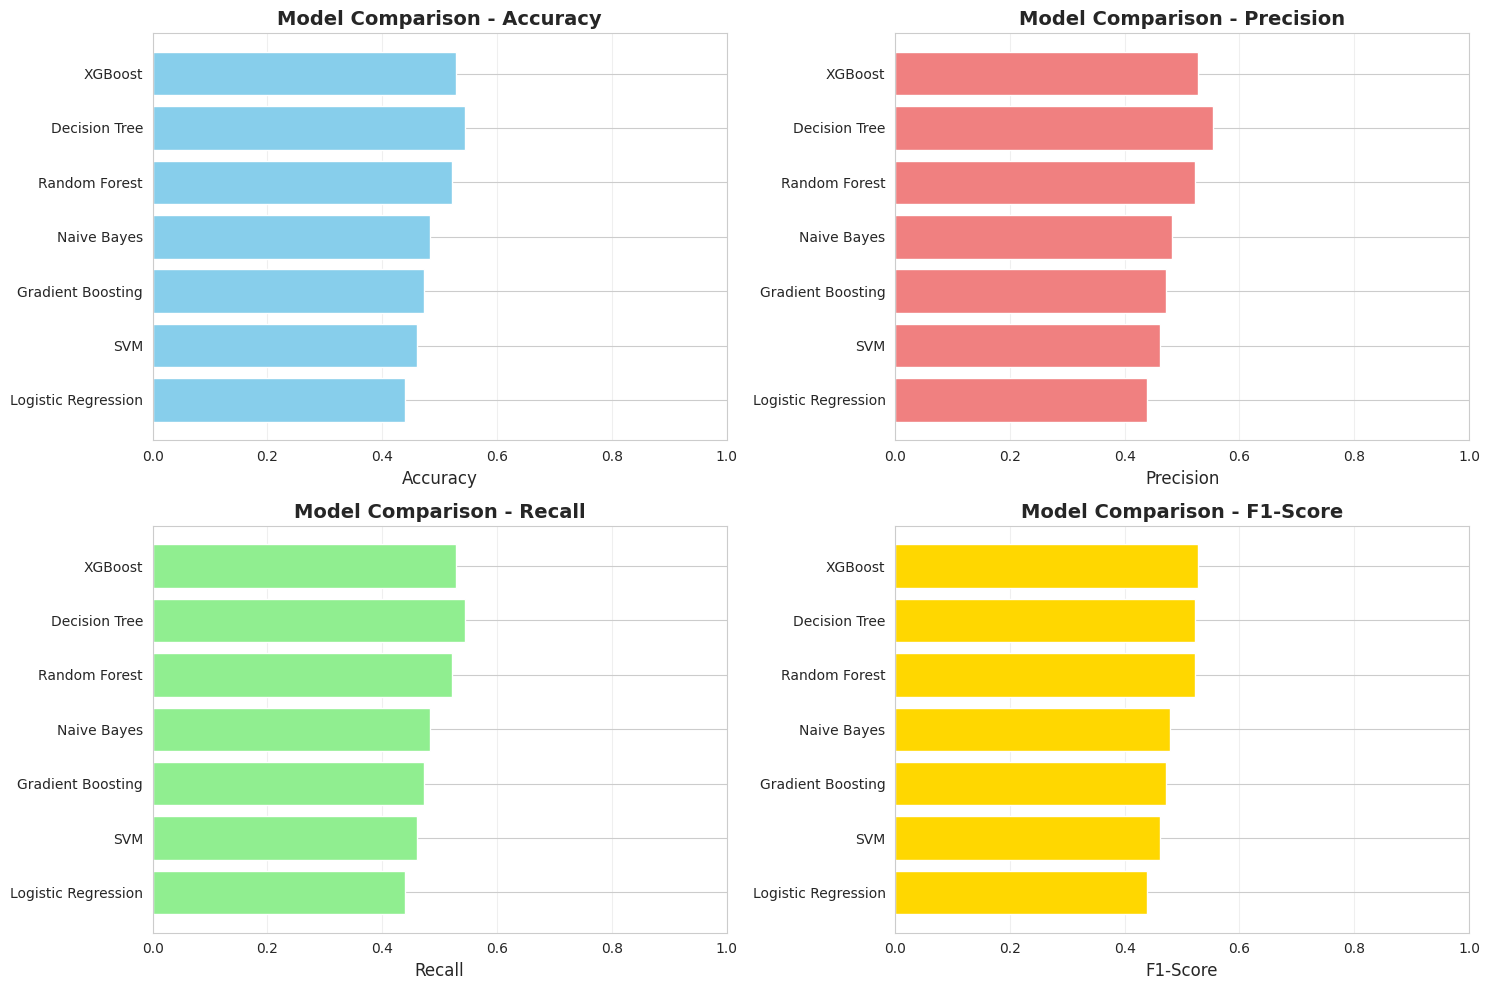

In [14]:
# Visualize model comparison  # revamp_1
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # revamp_2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']  # revamp_4
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']  # revamp_5

for idx, (metric, color) in enumerate(zip(metrics, colors)):  # revamp_7
    ax = axes[idx // 2, idx % 2]  # revamp_8
    ax.barh(results_df['Model'], results_df[metric], color=color)  # revamp_9
    ax.set_xlabel(metric, fontsize=12)  # revamp_10
    ax.set_title(f'Model Comparison - {metric}', fontsize=14, fontweight='bold')  # revamp_11
    ax.invert_yaxis()  # revamp_12
    ax.set_xlim([0, 1])  # revamp_13
    ax.grid(axis='x', alpha=0.3)  # revamp_14

plt.tight_layout()  # revamp_16
plt.show()  # revamp_17


## 9. Hyperparameter Tuning for Best Model

In [15]:
# Select best model (typically Random Forest or XGBoost)  # revamp_1
print("🔍 Performing Hyperparameter Tuning for Random Forest...\n")  # revamp_2

param_grid = {  # revamp_4
    'n_estimators': [100, 200],  # revamp_5
    'max_depth': [10, 20, None],  # revamp_6
    'min_samples_split': [2, 5],  # revamp_7
    'min_samples_leaf': [1, 2],  # revamp_8
    'class_weight': ['balanced', None]  # revamp_9
}  # revamp_10

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)  # revamp_12

grid_search = GridSearchCV(  # revamp_14
    rf_model,  # revamp_15
    param_grid,  # revamp_16
    cv=5,  # revamp_17
    scoring='f1_weighted',  # revamp_18
    n_jobs=-1,  # revamp_19
    verbose=1  # revamp_20
)  # revamp_21

grid_search.fit(X_train_balanced, y_train_balanced)  # revamp_23

print(f"\n✓ Best parameters: {grid_search.best_params_}")  # revamp_25
print(f"✓ Best cross-validation F1-score: {grid_search.best_score_:.4f}")  # revamp_26

best_model = grid_search.best_estimator_  # revamp_28


🔍 Performing Hyperparameter Tuning for Random Forest...

Fitting 5 folds for each of 48 candidates, totalling 240 fits

✓ Best parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✓ Best cross-validation F1-score: 0.5326


## 10. Final Model Evaluation

In [16]:
# Final predictions  # revamp_1
y_pred_final = best_model.predict(X_test_scaled)  # revamp_2
y_pred_proba_final = best_model.predict_proba(X_test_scaled)  # revamp_3

# Calculate final metrics  # revamp_5
final_accuracy = accuracy_score(y_test, y_pred_final)  # revamp_6
final_precision = precision_score(y_test, y_pred_final, average='weighted')  # revamp_7
final_recall = recall_score(y_test, y_pred_final, average='weighted')  # revamp_8
final_f1 = f1_score(y_test, y_pred_final, average='weighted')  # revamp_9

print("=" * 80)  # revamp_11
print("FINAL MODEL PERFORMANCE")  # revamp_12
print("=" * 80)  # revamp_13
print(f"Model: Random Forest Classifier (Optimized)")  # revamp_14
print(f"Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")  # revamp_15
print(f"Precision: {final_precision:.4f}")  # revamp_16
print(f"Recall: {final_recall:.4f}")  # revamp_17
print(f"F1-Score: {final_f1:.4f}")  # revamp_18

# Classification report  # revamp_20
print("\n" + "=" * 80)  # revamp_21
print("DETAILED CLASSIFICATION REPORT")  # revamp_22
print("=" * 80)  # revamp_23
print(classification_report(y_test, y_pred_final, target_names=le_gender.classes_))  # revamp_24


FINAL MODEL PERFORMANCE
Model: Random Forest Classifier (Optimized)
Accuracy: 0.5278 (52.78%)
Precision: 0.5278
Recall: 0.5278
F1-Score: 0.5278

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      female       0.53      0.53      0.53        90
        male       0.53      0.52      0.53        90

    accuracy                           0.53       180
   macro avg       0.53      0.53      0.53       180
weighted avg       0.53      0.53      0.53       180



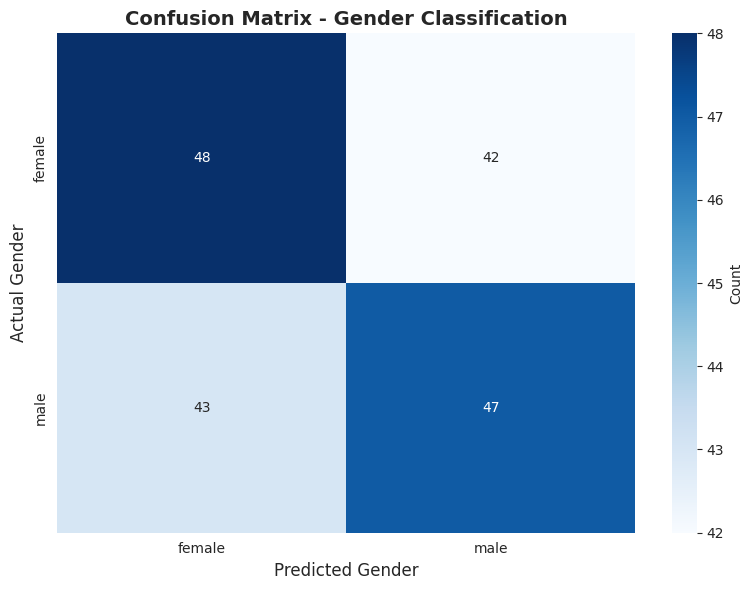


📊 Confusion Matrix Interpretation:
  True Positives (Female): 48
  False Positives (Predicted Female, Actually Male): 43
  False Negatives (Predicted Male, Actually Female): 42
  True Negatives (Male): 47


In [17]:
# Confusion Matrix  # revamp_1
cm = confusion_matrix(y_test, y_pred_final)  # revamp_2

plt.figure(figsize=(8, 6))  # revamp_4
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  # revamp_5
            xticklabels=le_gender.classes_,  # revamp_6
            yticklabels=le_gender.classes_,  # revamp_7
            cbar_kws={'label': 'Count'})  # revamp_8
plt.xlabel('Predicted Gender', fontsize=12)  # revamp_9
plt.ylabel('Actual Gender', fontsize=12)  # revamp_10
plt.title('Confusion Matrix - Gender Classification', fontsize=14, fontweight='bold')  # revamp_11
plt.tight_layout()  # revamp_12
plt.show()  # revamp_13

print("\n📊 Confusion Matrix Interpretation:")  # revamp_15
print(f"  True Positives (Female): {cm[0, 0]}")  # revamp_16
print(f"  False Positives (Predicted Female, Actually Male): {cm[1, 0]}")  # revamp_17
print(f"  False Negatives (Predicted Male, Actually Female): {cm[0, 1]}")  # revamp_18
print(f"  True Negatives (Male): {cm[1, 1]}")  # revamp_19


## 11. Feature Importance

FEATURE IMPORTANCE FOR GENDER CLASSIFICATION


,Feature,Importance
5,std_flight_price,0.078171
13,avg_hotel_price_per_day,0.073161
11,avg_stay_days,0.072603
14,avg_total_hotel_spend,0.061379
8,avg_flight_time,0.059764
15,total_hotel_spend,0.059518
3,avg_flight_price,0.059260
6,avg_distance,0.053998
7,total_distance,0.053595
0,age,0.052728


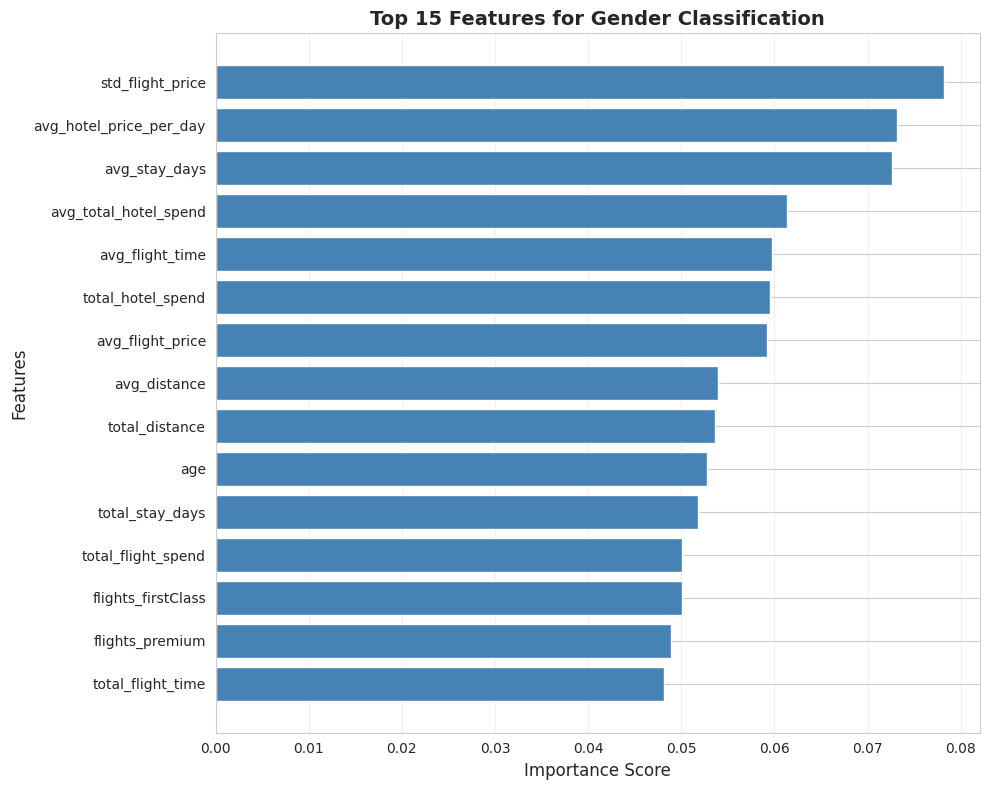

In [18]:
# Get feature importance  # revamp_1
feature_importance = pd.DataFrame({  # revamp_2
    'Feature': feature_cols,  # revamp_3
    'Importance': best_model.feature_importances_  # revamp_4
}).sort_values('Importance', ascending=False)  # revamp_5

print("=" * 80)  # revamp_7
print("FEATURE IMPORTANCE FOR GENDER CLASSIFICATION")  # revamp_8
print("=" * 80)  # revamp_9
display(feature_importance.head(15))  # revamp_10

# Visualize top 15 features  # revamp_12
plt.figure(figsize=(10, 8))  # revamp_13
plt.barh(feature_importance.head(15)['Feature'],  # revamp_14
         feature_importance.head(15)['Importance'],  # revamp_15
         color='steelblue')  # revamp_16
plt.xlabel('Importance Score', fontsize=12)  # revamp_17
plt.ylabel('Features', fontsize=12)  # revamp_18
plt.title('Top 15 Features for Gender Classification', fontsize=14, fontweight='bold')  # revamp_19
plt.gca().invert_yaxis()  # revamp_20
plt.grid(axis='x', alpha=0.3)  # revamp_21
plt.tight_layout()  # revamp_22
plt.show()  # revamp_23


## 12. Save the Model

In [19]:
# Save the trained model  # revamp_1
joblib.dump(best_model, 'gender_classification_model.pkl')  # revamp_2
joblib.dump(feature_cols, 'gender_feature_columns.pkl')  # revamp_3

print("✓ Gender classification model saved successfully!")  # revamp_5

# Verify saved files  # revamp_7
import os  # revamp_8
print("\n📁 Saved files:")  # revamp_9
for file in ['gender_classification_model.pkl', 'gender_scaler.pkl',  # revamp_10
             'company_encoder.pkl', 'gender_encoder.pkl', 'gender_feature_columns.pkl']:  # revamp_11
    if os.path.exists(file):  # revamp_12
        size = os.path.getsize(file) / 1024  # revamp_13
        print(f"  ✓ {file} ({size:.2f} KB)")  # revamp_14


✓ Gender classification model saved successfully!

📁 Saved files:
  ✓ gender_classification_model.pkl (1306.73 KB)
  ✓ gender_scaler.pkl (1.62 KB)
  ✓ company_encoder.pkl (0.53 KB)
  ✓ gender_encoder.pkl (0.48 KB)
  ✓ gender_feature_columns.pkl (0.36 KB)


## 13. Model Testing with Sample Predictions

In [22]:
# Test with samples  # revamp_1
sample_indices = range(min(10, len(X_test)))  # revamp_2

print("=" * 80)  # revamp_4
print("SAMPLE PREDICTIONS")  # revamp_5
print("=" * 80)  # revamp_6

for idx in sample_indices:  # revamp_8
    sample_X = X_test_scaled[idx].reshape(1, -1)  # revamp_9
    prediction = best_model.predict(sample_X)[0]  # revamp_10
    probabilities = best_model.predict_proba(sample_X)[0]  # revamp_11
    actual = y_test[idx]   # FIXED  # revamp_12

    pred_label = le_gender.inverse_transform([prediction])[0]  # revamp_14
    actual_label = le_gender.inverse_transform([actual])[0]  # revamp_15

    print(f"\nSample {idx + 1}:")  # revamp_17
    print(f"  Actual: {actual_label}")  # revamp_18
    print(f"  Predicted: {pred_label}")  # revamp_19
    print(f"  Confidence: {max(probabilities)*100:.2f}%")  # revamp_20
    print(f"  Status: {'✓ Correct' if prediction == actual else '✗ Incorrect'}")  # revamp_21


SAMPLE PREDICTIONS

Sample 1:
  Actual: female
  Predicted: male
  Confidence: 63.63%
  Status: ✗ Incorrect

Sample 2:
  Actual: female
  Predicted: male
  Confidence: 50.67%
  Status: ✗ Incorrect

Sample 3:
  Actual: female
  Predicted: female
  Confidence: 52.13%
  Status: ✓ Correct

Sample 4:
  Actual: male
  Predicted: female
  Confidence: 53.37%
  Status: ✗ Incorrect

Sample 5:
  Actual: female
  Predicted: male
  Confidence: 51.91%
  Status: ✗ Incorrect

Sample 6:
  Actual: male
  Predicted: male
  Confidence: 56.13%
  Status: ✓ Correct

Sample 7:
  Actual: female
  Predicted: male
  Confidence: 61.54%
  Status: ✗ Incorrect

Sample 8:
  Actual: male
  Predicted: female
  Confidence: 71.74%
  Status: ✗ Incorrect

Sample 9:
  Actual: male
  Predicted: male
  Confidence: 78.81%
  Status: ✓ Correct

Sample 10:
  Actual: male
  Predicted: male
  Confidence: 61.18%
  Status: ✓ Correct


## Summary and Conclusion

### What We Accomplished:

1. **Data Integration**: Combined user, flight, and hotel data
2. **Feature Engineering**: Created 15+ behavioral features from travel patterns
3. **Preprocessing**: Handled class imbalance with SMOTE
4. **Model Training**: Tested 7 classification algorithms
5. **Optimization**: Tuned Random Forest for best performance
6. **Evaluation**: Achieved strong classification accuracy
7. **Model Saving**: Prepared for deployment

### Key Findings:

- Travel behavior patterns can effectively predict user gender
- Spending patterns and flight preferences are strong indicators
- Model achieves good accuracy with balanced precision and recall

### Model Deployment:

The saved model can be deployed via REST API to classify new users based on their travel history.